# 분석 환경 세팅하기

In [89]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 53.5 MB/s eta 0:00:00


In [90]:
# 라이브러리 불러오기
import numpy as np # 수치연산
import pandas as pd # 데이터프레임 다루기
import seaborn as sns # 한두 줄의 코드로 시각화
import matplotlib.pyplot as plt # 세부적인 커스터마이징
import koreanize_matplotlib # 그래프 그릴 때 한국어 지원

In [3]:
# 현재 작업 디렉토리 확인
import os

os.getcwd()

'/content'

# 1\. 데이터 불러오기

In [4]:
# 데이터 불러오기
orders_df = pd.read_csv('/content/orders.csv')
pizzas_df = pd.read_csv('/content/pizzas.csv')
pizza_types_df = pd.read_csv('/content/pizza_types.csv')

In [8]:
orders_df.head(10)

,order_id,order_timestamp,order_details_id,pizza_id,quantity
0,1,2023-01-01 11:45:11,1,hawaiian_m,1
1,2,2023-01-01 11:53:26,2,big_meat_l,1
2,2,2023-01-01 11:53:26,3,classic_dlx_m,1
3,2,2023-01-01 11:53:26,4,five_cheese_l,1
4,2,2023-01-01 11:53:26,5,potato_m,1
5,2,2023-01-01 11:53:26,6,thai_ckn_l,1
6,3,2023-01-01 11:54:22,7,pepperoni_l,1
7,3,2023-01-01 11:54:22,8,super_supreme_m,1
8,4,2023-01-01 12:09:18,9,big_meat_m,1
9,5,2023-01-01 12:15:29,10,super_supreme_m,1


In [11]:
orders_df['order_details_id'].count(), orders_df['order_details_id'].nunique() # order_details_id는 중복이 없으므로 orders 데이터의 고유값이 됨

(np.int64(47079), 47079)

In [12]:
orders_df.shape # 47079행, 5열

(47079, 5)

In [13]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47079 entries, 0 to 47078
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_id          47079 non-null  int64 
 1   order_timestamp   47079 non-null  object
 2   order_details_id  47079 non-null  int64 
 3   pizza_id          47079 non-null  object
 4   quantity          47079 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 1.8+ MB


In [6]:
pizzas_df.head()

,pizza_id,pizza_name,size,price
0,bbq_ckn_s,바비큐 치킨 피자,S,11300
1,bbq_ckn_m,바비큐 치킨 피자,M,22000
2,bbq_ckn_l,바비큐 치킨 피자,L,34000
3,thai_ckn_s,타이 치킨 피자,S,12300
4,thai_ckn_m,타이 치킨 피자,M,24000


In [14]:
pizzas_df['pizza_id'].count(), pizzas_df['pizza_id'].nunique()

(np.int64(39), 39)

In [15]:
pizzas_df.shape

(39, 4)

In [17]:
pizzas_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   pizza_id    39 non-null     object
 1   pizza_name  39 non-null     object
 2   size        39 non-null     object
 3   price       39 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 1.3+ KB


In [7]:
pizza_types_df.head()

,pizza_name,category,ingredients
0,바비큐 치킨 피자,치킨,"치킨, 피망, 토마토, 적양파, 바비큐 소스"
1,타이 치킨 피자,치킨,"치킨, 파인애플, 토마토, 피망, 타이 칠리 소스"
2,빅 미트 피자,클래식,"베이컨, 토마토, 페퍼로니, 살라미, 초리조"
3,클래식 디럭스 피자,클래식,"토마토, 페퍼로니, 버섯, 적양파, 피망, 베이컨"
4,슈퍼 슈프림 피자,클래식,"페퍼로니, 토마토, 적양파, 그린 올리브, 옥수수, 마늘"


In [18]:
pizza_types_df['pizza_name'].count(), pizza_types_df['pizza_name'].nunique()

(np.int64(13), 13)

In [19]:
pizza_types_df.shape

(13, 3)

In [20]:
pizza_types_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   pizza_name   13 non-null     object
 1   category     13 non-null     object
 2   ingredients  13 non-null     object
dtypes: object(3)
memory usage: 444.0+ bytes


# 2\. 데이터 전처리

In [24]:
# 데이터 중복값 파악하기
print(orders_df.duplicated().sum())
print(pizzas_df.duplicated().sum())
print(pizza_types_df.duplicated().sum())

0
0
0


In [27]:
# 데이터 결측값 파악하기
print(orders_df.isna().sum().sum())
print(pizzas_df.isna().sum().sum())
print(pizza_types_df.isna().sum().sum())

0
0
0


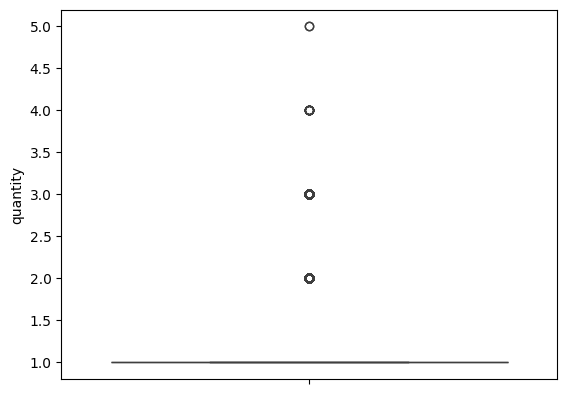

In [28]:
# 데이터 이상치 파악하기 : orders_df의 quantity 컬럼
sns.boxplot(orders_df['quantity'])
plt.show()

In [29]:
orders_df['quantity'].value_counts()

,count
quantity,
1,44766
2,2148
3,150
4,13
5,2


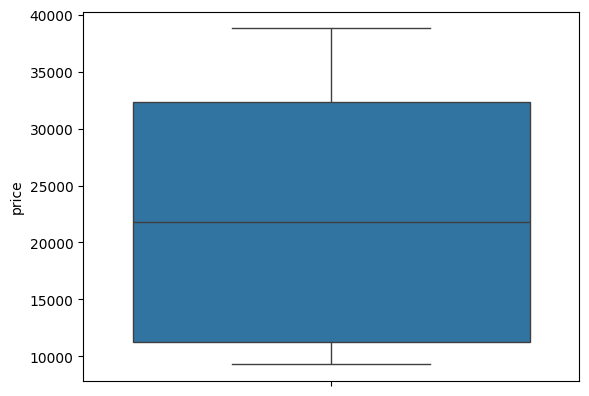

In [30]:
# 데이터 이상치 파악하기 : pizzas_df price 컬럼
sns.boxplot(pizzas_df['price'])
plt.show()

In [35]:
# 데이터 결합하기
merge_order_piza = pd.merge(orders_df, pizzas_df, on = 'pizza_id', how = 'left')
merge_order_piza.shape
merge_order_piza.head()

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price
0,1,2023-01-01 11:45:11,1,hawaiian_m,1,하와이안 피자,M,21800
1,2,2023-01-01 11:53:26,2,big_meat_l,1,빅 미트 피자,L,34000
2,2,2023-01-01 11:53:26,3,classic_dlx_m,1,클래식 디럭스 피자,M,20300
3,2,2023-01-01 11:53:26,4,five_cheese_l,1,파이브 치즈 피자,L,31000
4,2,2023-01-01 11:53:26,5,potato_m,1,포테이토 피자,M,21800


In [34]:
pizza_orders_df = pd.merge(merge_order_piza, pizza_types_df, on = 'pizza_name', how = 'left')
pizza_orders_df.shape
pizza_orders_df.head()

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price,category,ingredients
0,1,2023-01-01 11:45:11,1,hawaiian_m,1,하와이안 피자,M,21800,스페셜,"토마토, 베이컨, 파인애플, 모짜렐라 치즈"
1,2,2023-01-01 11:53:26,2,big_meat_l,1,빅 미트 피자,L,34000,클래식,"베이컨, 토마토, 페퍼로니, 살라미, 초리조"
2,2,2023-01-01 11:53:26,3,classic_dlx_m,1,클래식 디럭스 피자,M,20300,클래식,"토마토, 페퍼로니, 버섯, 적양파, 피망, 베이컨"
3,2,2023-01-01 11:53:26,4,five_cheese_l,1,파이브 치즈 피자,L,31000,베지테리언,"모짜렐라 치즈, 프로볼로네 치즈, 고다 치즈, 페코리노 치즈, 고르곤졸라 치즈"
4,2,2023-01-01 11:53:26,5,potato_m,1,포테이토 피자,M,21800,스페셜,"모짜렐라 치즈, 토마토, 감자, 양파, 베이컨, 옥수수, 마요네즈"


In [37]:
pizza_orders_df['total_price'] = pizza_orders_df['quantity'] * pizza_orders_df['price']
pizza_orders_df.head()

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price,category,ingredients,total_price
0,1,2023-01-01 11:45:11,1,hawaiian_m,1,하와이안 피자,M,21800,스페셜,"토마토, 베이컨, 파인애플, 모짜렐라 치즈",21800
1,2,2023-01-01 11:53:26,2,big_meat_l,1,빅 미트 피자,L,34000,클래식,"베이컨, 토마토, 페퍼로니, 살라미, 초리조",34000
2,2,2023-01-01 11:53:26,3,classic_dlx_m,1,클래식 디럭스 피자,M,20300,클래식,"토마토, 페퍼로니, 버섯, 적양파, 피망, 베이컨",20300
3,2,2023-01-01 11:53:26,4,five_cheese_l,1,파이브 치즈 피자,L,31000,베지테리언,"모짜렐라 치즈, 프로볼로네 치즈, 고다 치즈, 페코리노 치즈, 고르곤졸라 치즈",31000
4,2,2023-01-01 11:53:26,5,potato_m,1,포테이토 피자,M,21800,스페셜,"모짜렐라 치즈, 토마토, 감자, 양파, 베이컨, 옥수수, 마요네즈",21800


# 3\. 데이터 탐색하기

In [44]:
pizza_orders_df.head(1)

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price,category,ingredients,total_price
0,1,2023-01-01 11:45:11,1,hawaiian_m,1,하와이안 피자,M,21800,스페셜,"토마토, 베이컨, 파인애플, 모짜렐라 치즈",21800


In [38]:
pizza_orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47079 entries, 0 to 47078
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   order_id          47079 non-null  int64 
 1   order_timestamp   47079 non-null  object
 2   order_details_id  47079 non-null  int64 
 3   pizza_id          47079 non-null  object
 4   quantity          47079 non-null  int64 
 5   pizza_name        47079 non-null  object
 6   size              47079 non-null  object
 7   price             47079 non-null  int64 
 8   category          47079 non-null  object
 9   ingredients       47079 non-null  object
 10  total_price       47079 non-null  int64 
dtypes: int64(5), object(6)
memory usage: 4.0+ MB


In [39]:
# 중복값 확인하기
pizza_orders_df.duplicated().sum()

np.int64(0)

In [40]:
# 결측값 확인하기
pizza_orders_df.isna().sum().sum()

np.int64(0)

In [41]:
# 기술 통계량 확인하기
pizza_orders_df.describe()

,order_id,order_details_id,quantity,price,total_price
count,47079.000000,47079.000000,47079.000000,47079.000000,47079.000000
mean,10708.712058,23540.000000,1.052996,22945.597825,24233.356698
std,6175.450615,13590.680998,0.242338,9376.523771,11887.470629
min,1.000000,1.000000,1.000000,9300.000000,9300.000000
25%,5352.500000,11770.500000,1.000000,11300.000000,12300.000000
50%,10696.000000,23540.000000,1.000000,21800.000000,22000.000000
75%,16100.500000,35309.500000,1.000000,32300.000000,33800.000000
max,21350.000000,47079.000000,5.000000,38800.000000,169000.000000


In [43]:
# 모든 컬럼의 기술 통계량 확인하기
pizza_orders_df.describe(include = 'all')

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price,category,ingredients,total_price
count,47079.000000,47079,47079.000000,47079,47079.000000,47079,47079,47079.000000,47079,47079,47079.000000
unique,NaN,21350,NaN,39,NaN,13,3,NaN,4,13,NaN
top,NaN,2023-11-18 21:10:53,NaN,thai_ckn_l,NaN,하와이안 피자,L,NaN,클래식,"토마토, 베이컨, 파인애플, 모짜렐라 치즈",NaN
freq,NaN,19,NaN,2495,NaN,5909,18378,NaN,17437,5909,NaN
mean,10708.712058,NaN,23540.000000,NaN,1.052996,NaN,NaN,22945.597825,NaN,NaN,24233.356698
std,6175.450615,NaN,13590.680998,NaN,0.242338,NaN,NaN,9376.523771,NaN,NaN,11887.470629
min,1.000000,NaN,1.000000,NaN,1.000000,NaN,NaN,9300.000000,NaN,NaN,9300.000000
25%,5352.500000,NaN,11770.500000,NaN,1.000000,NaN,NaN,11300.000000,NaN,NaN,12300.000000
50%,10696.000000,NaN,23540.000000,NaN,1.000000,NaN,NaN,21800.000000,NaN,NaN,22000.000000
75%,16100.500000,NaN,35309.500000,NaN,1.000000,NaN,NaN,32300.000000,NaN,NaN,33800.000000


In [45]:
# order_timestamp 날짜 데이터로 변환하기
pizza_orders_df['order_timestamp'] = pd.to_datetime(pizza_orders_df['order_timestamp'])
pizza_orders_df.dtypes

,0
order_id,int64
order_timestamp,datetime64[ns]
order_details_id,int64
pizza_id,object
quantity,int64
pizza_name,object
size,object
price,int64
category,object
ingredients,object


In [52]:
# 시간 컬럼 생성하기
pizza_orders_df['year'] = pizza_orders_df['order_timestamp'].dt.year # 연
pizza_orders_df['month'] = pizza_orders_df['order_timestamp'].dt.month # 월
pizza_orders_df['day_name'] = pizza_orders_df['order_timestamp'].dt.day_name() # n요일
pizza_orders_df['dayofweek'] = pizza_orders_df['order_timestamp'].dt.dayofweek # 요일 숫자로
pizza_orders_df['hour'] = pizza_orders_df['order_timestamp'].dt.hour # 시간대

pizza_orders_df.head(1)

,order_id,order_timestamp,order_details_id,pizza_id,quantity,pizza_name,size,price,category,ingredients,total_price,year,month,dayname,day_name,dayofweek,hour
0,1,2023-01-01 11:45:11,1,hawaiian_m,1,하와이안 피자,M,21800,스페셜,"토마토, 베이컨, 파인애플, 모짜렐라 치즈",21800,2023,1,Sunday,Sunday,6,11


In [55]:
# 2023년 데이터 상 첫 주문 일시, 마지막 주문 일시
print('첫 주문 일시', pizza_orders_df['order_timestamp'].min()) # 첫 주문 일시
print('마지막 주문 일시', pizza_orders_df['order_timestamp'].max()) # 마지막 주문 일시

첫 주문 일시 2023-01-01 11:45:11
마지막 주문 일시 2023-12-31 21:56:56


In [70]:
# 범주의 종류 개수 및 종류 파악하기
cat_cols = ['pizza_name', 'size', 'category']

for col in cat_cols:
  print('=' * 50)
  print(col)
  print('범주 종류의 개수:', pizza_orders_df[col].nunique())
  print('범주의 종류:', pizza_orders_df[col].unique(), '\n')

pizza_name
범주 종류의 개수: 13
범주의 종류: ['하와이안 피자' '빅 미트 피자' '클래식 디럭스 피자' '파이브 치즈 피자' '포테이토 피자' '타이 치킨 피자'
 '페퍼로니 피자' '슈퍼 슈프림 피자' '바비큐 치킨 피자' '프로슈토 루꼴라 피자' '그린 가든 피자' '시금치 페스토 피자'
 '불고기 피자'] 

size
범주 종류의 개수: 3
범주의 종류: ['M' 'L' 'S'] 

category
범주 종류의 개수: 4
범주의 종류: ['스페셜' '클래식' '베지테리언' '치킨'] 



In [59]:
pizza_orders_df[cat_cols]

,pizza_name,size,category
0,하와이안 피자,M,스페셜
1,빅 미트 피자,L,클래식
2,클래식 디럭스 피자,M,클래식
3,파이브 치즈 피자,L,베지테리언
4,포테이토 피자,M,스페셜
...,...,...,...
47074,불고기 피자,M,스페셜
47075,포테이토 피자,L,스페셜
47076,슈퍼 슈프림 피자,S,클래식
47077,불고기 피자,L,스페셜


In [71]:
pizza_orders_df[['category', 'pizza_name']].drop_duplicates().sort_values(by = 'category')

,category,pizza_name
3,베지테리언,파이브 치즈 피자
16,베지테리언,그린 가든 피자
19,베지테리언,시금치 페스토 피자
0,스페셜,하와이안 피자
4,스페셜,포테이토 피자
11,스페셜,프로슈토 루꼴라 피자
28,스페셜,불고기 피자
5,치킨,타이 치킨 피자
10,치킨,바비큐 치킨 피자
1,클래식,빅 미트 피자


# 4\. 데이터 분석하기

## (1) 종합 결산(2023년)

In [82]:
# 영업일
total_days = pizza_orders_df['order_timestamp'].dt.date.nunique()
print(f'영업일: {total_days}일')

# 주문건수
total_orders = pizza_orders_df['order_id'].nunique()
print(f'주문건수: {total_orders}건')

# 총매출
total_sales = pizza_orders_df['total_price'].sum()
print(f'총매출: {total_sales:,.0f}원') # 천 단위 , 추가

# 하루 평균 매출
sales_per_day = total_sales / total_days
print(f'하루 평균 매출: {sales_per_day:,.0f}원') # 천 단위 , 추가

# 총 판매량
total_quantity = pizza_orders_df['quantity'].sum()
print(f'총 판매량: {total_quantity:,.0f}판') # 천 단위 , 추가

# 하루 평균 판매량
quantity_per_day = total_quantity / total_days
print(f'하루 평균 판매량: {quantity_per_day}판')

영업일: 358일
주문건수: 21350건
총매출: 1,140,882,200원
하루 평균 매출: 3,186,822원
총 판매량: 49,574판
하루 평균 판매량: 138.47486033519553판


## (2) 시간에 따른 매출

### 월별 매출

In [86]:
sales_by_month = pizza_orders_df.groupby(['month'])['total_price'].sum().reset_index()
sales_by_month

,month,total_price
0,1,93718700
1,2,89392300
2,3,98494600
3,4,96277400
4,5,100225300
5,6,95518100
6,7,101553600
7,8,94873600
8,9,89302500
9,10,88423800


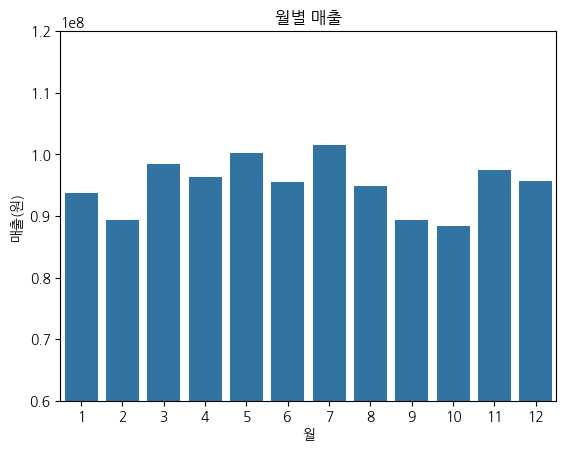

In [96]:
sns.barplot(data = sales_by_month, x = 'month', y = 'total_price')

plt.title('월별 매출')
plt.xlabel('월')
plt.ylabel('매출(원)')
plt.ylim([60000000, 120000000])

plt.show()

2023년에는 1월부터 7월까지는 전반적으로 상승세이고, 7월에 최대 매출을 기록했다.
이후 세 달 연속 매출이 하락하여 10월에는 매출이 가장 저조했다.

### 요일별 매출

In [97]:
sales_by_day = pizza_orders_df.groupby(['day_name'])['total_price'].sum().reset_index() # 총매출
sales_by_day

,day_name,total_price
0,Friday,185106800
1,Monday,147541300
2,Saturday,169516300
3,Sunday,143080900
4,Thursday,168921600
5,Tuesday,160866900
6,Wednesday,165848400


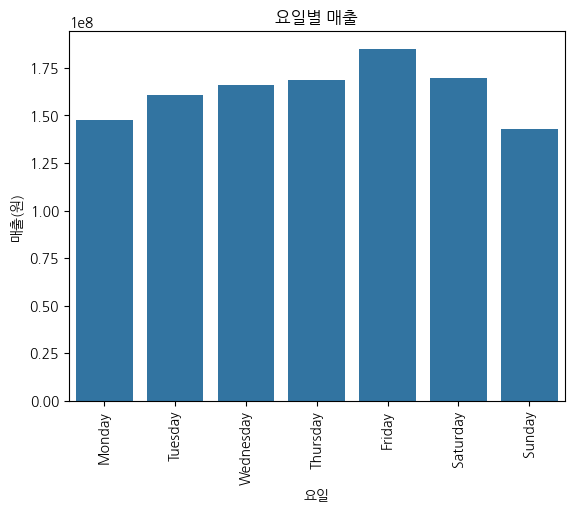

In [101]:
sns.barplot(data = sales_by_day, x = 'day_name', y = 'total_price', order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.title('요일별 매출')
plt.xlabel('요일')
plt.ylabel('매출(원)')
plt.xticks(rotation = 90) # x축 눈금 이름 각도 설정

plt.show()

금요일에 매출이 가장 높았고, 상대적으로 일요일과 월요일은 매출이 저조한 편임을 알 수 있다

### 시간대별 매출

In [102]:
sales_by_hour = pizza_orders_df.groupby(['hour'])['total_price'].sum().reset_index()
sales_by_hour

,hour,total_price
0,10,461000
1,11,64896300
2,12,131185900
3,13,140566100
4,14,82838800
5,15,81688100
6,16,106494800
7,17,122837100
8,18,124612100
9,19,102778400


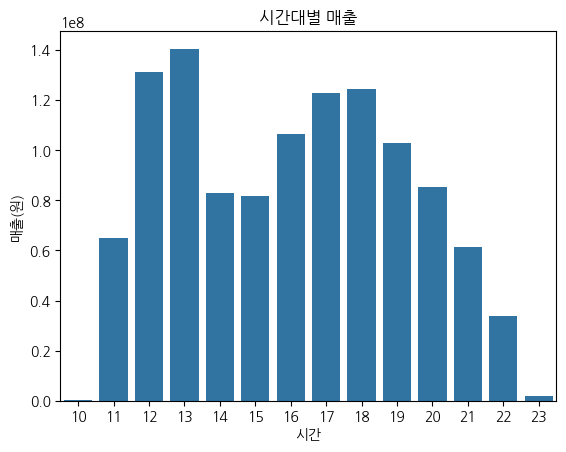

In [105]:
sns.barplot(data = sales_by_hour, x = 'hour', y = 'total_price')

plt.title('시간대별 매출')
plt.xlabel('시간대ㅈ점')
plt.ylabel('매출(원)')

plt.show()

점심과 저녁 시간대에 매출이 집중된 편이다. 따라서, 그만큼 처리해야할 주문이 많을 테니 인력이 부족하기 않도록 신경을 써야할 것이다. 애매한 오후 시간대와 밤 시간대에는 매출이 다소 아쉬운 상황이므로 이런 시간대에는 할인 혜택이나 서비스 메뉴를 제공하는 식으로 매출 상승 유도를 고려해볼 수 있다.


### 평일과 주말의 시간대별 매출

In [106]:
pizza_orders_df['dayofweek'].unique()

array([6, 0, 1, 2, 3, 4, 5], dtype=int32)

In [109]:
# type_of_day : 평일인지 주말인지 구분
pizza_orders_df['type_of_day'] = pizza_orders_df['dayofweek'].apply(lambda x: '주말'if x >= 5 else '평일') # x -> 요일
pizza_orders_df['type_of_day'].head()

,type_of_day
0,주말
1,주말
2,주말
3,주말
4,주말


In [111]:
sales_by_day_hour = pizza_orders_df.groupby(['type_of_day', 'hour'])['total_price'].sum().reset_index()
sales_by_day_hour.head()

,type_of_day,hour,total_price
0,주말,10,100900
1,주말,11,11228800
2,주말,12,22257900
3,주말,13,28416200
4,주말,14,26884100


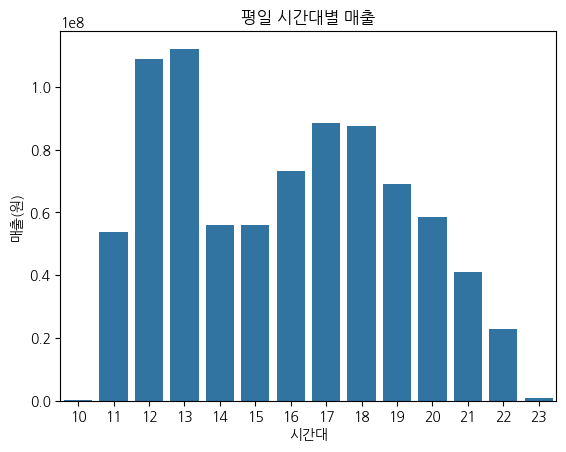

In [113]:
# 평일 시간대별 매출
weekday_sales = sales_by_day_hour.query("type_of_day == '평일'")

sns.barplot(data = weekday_sales, x = 'hour', y = 'total_price')
plt.title('평일 시간대별 매출')
plt.xlabel('시간대')
plt.ylabel('매출(원)')

plt.show()

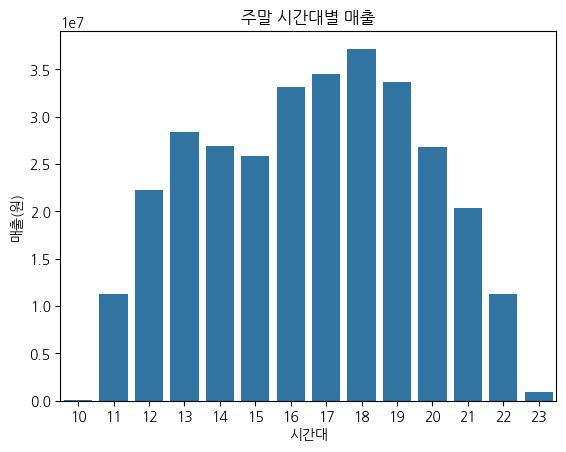

In [115]:
# 주말 시간대별 매출
weekend_sales = sales_by_day_hour.query("type_of_day == '주말'")

sns.barplot(data = weekend_sales, x = 'hour', y = 'total_price')
plt.title('주말 시간대별 매출')
plt.xlabel('시간대')
plt.ylabel('매출(원)')

plt.show()

평일에는 점심 시간이 저녁 시간보다 매출이 잘 나오는 반면, 주말에는 반대로 저녁 시간이 점심 시간보다 매출이 더 잘 나오는 것을 확인할 수 있다.
심지어 주말에는 점심 시간과 저녁 시간 사이인 14시부터 17시까지의 구간의 매출도 꽤 높다.
평일과 주말의 특수성을 고려하여 인력을 배분하면 더 수월하게 영업할 수 있을 것으로 보인다.

## (3) 피자 메뉴에 따른 판매량

### 피자 메뉴별 판매량

In [119]:
quantity_by_pizza = pizza_orders_df.groupby(['pizza_name'])['quantity'].sum().reset_index().sort_values(by = 'quantity', ascending = False)
quantity_by_pizza

,pizza_name,quantity
12,하와이안 피자,6316
9,페퍼로니 피자,6291
7,타이 치킨 피자,5432
6,클래식 디럭스 피자,4691
3,빅 미트 피자,4145
1,바비큐 치킨 피자,4065
8,파이브 치즈 피자,3609
10,포테이토 피자,3291
4,슈퍼 슈프림 피자,3279
0,그린 가든 피자,2621


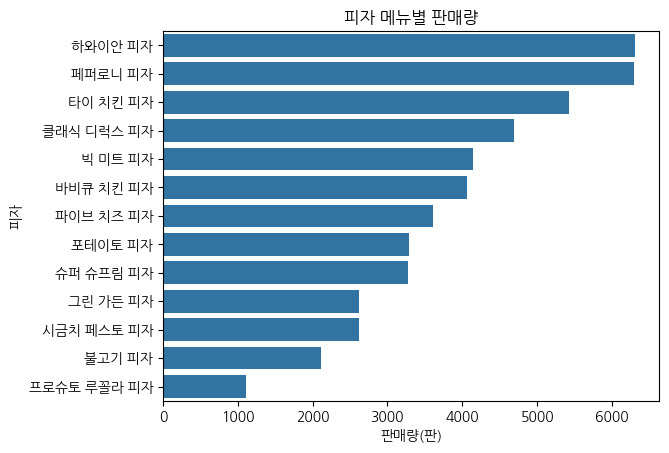

In [124]:
sns.barplot(data = quantity_by_pizza, x = 'quantity', y = 'pizza_name') # seaborn

plt.title('피자 메뉴별 판매량') # matplotlib
plt.xlabel('판매량(판)')
plt.ylabel('피자')

plt.show()

### 각 피자 메뉴별 월별 판매량

In [126]:
quantity_by_pizza_and_month = pizza_orders_df.groupby(['pizza_name', 'month'])['quantity'].sum().reset_index()
quantity_by_pizza_and_month

,pizza_name,month,quantity
0,그린 가든 피자,1,222
1,그린 가든 피자,2,212
2,그린 가든 피자,3,267
3,그린 가든 피자,4,209
4,그린 가든 피자,5,233
...,...,...,...
151,하와이안 피자,8,538
152,하와이안 피자,9,498
153,하와이안 피자,10,473
154,하와이안 피자,11,533


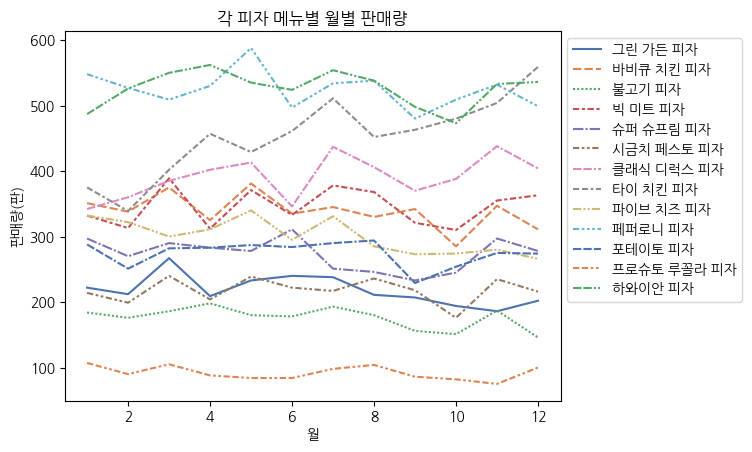

In [133]:
sns.lineplot(data = quantity_by_pizza_and_month, x = 'month', y = 'quantity', hue = 'pizza_name', style = 'pizza_name', palette = 'deep')

plt.title('각 피자 메뉴별 월별 판매량')
plt.xlabel('월')
plt.ylabel('판매량(판)')
plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1))

plt.show()

- 인기메뉴인 하와이안 피자와 페퍼로니 피자는 꾸준히 상위권을 차지한다

- 타이 치킨 피자는 1년동안 판매량이 크게 상승하여 12월에는 가장 많이 팔린 메뉴가 되었다. 따라서, 판매량이 꾸준히 상승한 이유를 파악해 두면 앞으로 메뉴를 개발하거나 관리하는데 도움이 될 것이다.

- 프로슈토 루꼴라 피자와 불고기 피자는 판매량이 낮다.

### 각 피자 메뉴별 사이즈별 판매량

In [135]:
quantity_by_pizza_and_size = pizza_orders_df.groupby(['pizza_name', 'size'])['quantity'].sum().reset_index()
quantity_by_pizza_and_size.head()

,pizza_name,size,quantity
0,그린 가든 피자,L,746
1,그린 가든 피자,M,884
2,그린 가든 피자,S,991
3,바비큐 치킨 피자,L,1674
4,바비큐 치킨 피자,M,1528


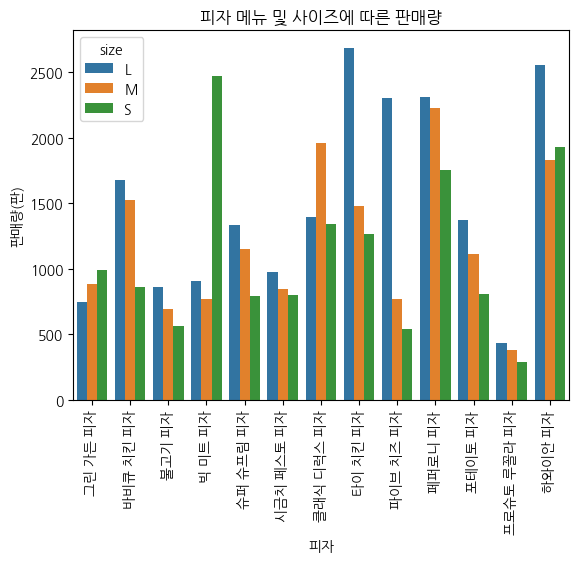

In [140]:
sns.barplot(data = quantity_by_pizza_and_size, x = 'pizza_name', y = 'quantity', hue = 'size')

plt.xticks(rotation = 90)
plt.title('피자 메뉴 및 사이즈에 따른 판매량')
plt.xlabel('피자')
plt.ylabel('판매량(판)')

plt.show()

- 총 13가지 피자 메뉴에서 L 사이즈의 판매량이 가장 많은 것으로 보아ㄷ대체로 L 사이즈 피자의 인기가 가장 많다.

- M 사이즈의 판매량이 가장 많은 피자는 클래식 디럭스 피자 뿐이다.

- S 사이즈의 판매량이 가장 많은 피자는 그린 가든 피자와 빅 미트 피자이다.

- 빅 미트 피자, 타이 치킨 피자, 파이브 치즈 피자는 사이즈별로 판매량 차이가 많이 나는데, 왜 그런지 원인을 파악하고 특정 사이즈의 판매량이 부진하지 않도록 대책을 마련하는게 좋다.

## (4) 피자 카테고리별 판매량

In [143]:
quantity_by_category = pizza_orders_df.groupby(['category'])['quantity'].sum().reset_index().sort_values(by = 'quantity', ascending = False)
quantity_by_category

,category,quantity
3,클래식,18406
1,스페셜,12825
2,치킨,9497
0,베지테리언,8846


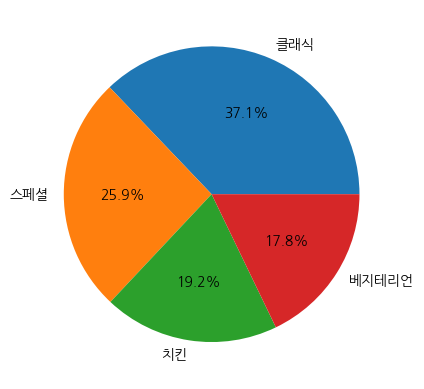

In [147]:
plt.pie(quantity_by_category['quantity'], labels = quantity_by_category['category'], autopct = '%.1f%%')
plt.show()

- 판매량 기준으로 클래식 > 베지테리언 > 치킨 > 스페셜인데, 속한 피자 메뉴의 개수에 따른 것 일수도 있으므로 추가적으로 각 카테고리에 속한 피자의 개수를 비교할 필요가 있다.

In [148]:
pizza_orders_df.groupby(['category'])['pizza_name'].nunique().reset_index().sort_values(by = 'pizza_name', ascending = False)

,category,pizza_name
1,스페셜,4
3,클래식,4
0,베지테리언,3
2,치킨,2


In [149]:
quantity_by_category_pizza = pizza_orders_df.groupby(['category', 'pizza_name'])['quantity'].sum().reset_index()
quantity_by_category_pizza

,category,pizza_name,quantity
0,베지테리언,그린 가든 피자,2621
1,베지테리언,시금치 페스토 피자,2616
2,베지테리언,파이브 치즈 피자,3609
3,스페셜,불고기 피자,2115
4,스페셜,포테이토 피자,3291
5,스페셜,프로슈토 루꼴라 피자,1103
6,스페셜,하와이안 피자,6316
7,치킨,바비큐 치킨 피자,4065
8,치킨,타이 치킨 피자,5432
9,클래식,빅 미트 피자,4145


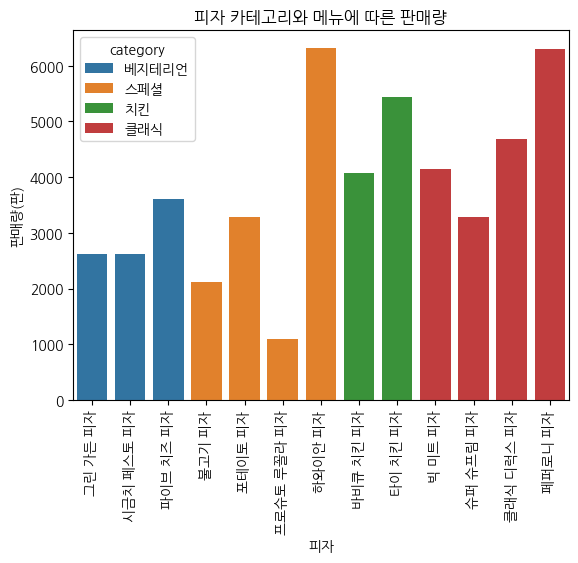

In [151]:
sns.barplot(data = quantity_by_category_pizza, x = 'pizza_name', y = 'quantity', hue = 'category')

plt.title('피자 카테고리와 메뉴에 따른 판매량')
plt.xlabel('피자')
plt.ylabel('판매량(판)')
plt.xticks(rotation = 90)

plt.show()

- 클래식 피자 : 카테고리 판매량 1위였고, 대체로 잘 팔리는 것을 알 수 있다.

- 스페셜 피자 : 카테고리 판매량 2위였고, 사실상 하와이안 피자를 제외하면 판매량이 저조한 편이다.

- 치킨 피자 : 카테고리 판매량 3위였고, 피자 메뉴가 2개 뿐이지만 모두 잘 팔리는 것을 알 수 있다.

- 베지테리언 피자 : 카테고리 판매량 4위였다. 다른 카테고리에 비해 판매량이 적고, 그나마 파이브 치즈 피자가 채소 위주의 피자보다 잘 팔린다. 베지테리언 피자는 타겟 고객층이 한정된 편이라 판매량이 아주 높게 나오기는 어려운 것으로 보인다.